# Explanatory Data Analysis on UCF Parking Garage Data

## Table of Contents

1. [**Introduction**](#1)
    - Project Description
    - Data Description
2. [**Acquiring and Loading Data**](#2)
	- Importing Libraries and Notebook Setup
    - Loading Data
    - Basic Data Exploration
    - Areas to Fix
3. [**Data Proprocessing**](#3)
4. [**Data Analysis**](#4)
5. [**Conclusion**](#5)
    - Insights
    - Suggestions
    - Possible Next Steps
6. [**Epilogue**](#6) 
    - References
    - Versioning

---

# 1

## Introduction

### Project Description

**Goal/Purpose:** 

This project, parkUCF, aims to facilitate student parking at the University of Central Florida's parking garages. The objective is to deploy an application that leverages machine learning predictions to display information and insights to students regarding the expected garage occupancy for the day. This notebook will outline and document the process of explanatory data analysis, and its findings will be instrumental to the completion of parkUCF.

<p>&nbsp;</p>

**Questions to be Answered:**

- Do time formatting issues cause problems in the dataset?
- What are the busiest and least busy garages and days of the week?
- How similar are occupancy trends from day to day?

<p>&nbsp;</p>

**Assumptions/Methodology/Scope:** 

Assumptions:

- All timestamps are timezone-aware/in UTC
- The device which scans license plates returns accurate vehicle counts
- The number of occupied spots represents the number of vehicles inside the garage

Methodology/processing steps:

- Data inspection, cleaning and preprocessing
- Multivariate analysis
- Feature engineering
- Visualization

Scope:

- Exploring and understanding the dataset
- Only the data provided is analyzed

<p>&nbsp;</p>

### Data Description

**Content:** 

This dataset is a JSON file of 25989 data points which contains parking garage data from 5 UCF parking garages (garages A, B, C, D, and H). 

<p>&nbsp;</p>

**Description of Attributes:** 

| Column  | Description |
| :------ | :---------- |
| name    | Name of the garage|
|available| total - amount of vehicles in garage|
|occupied | Amount of vehicles in garage|
|total    | Total amount of spots in garage |
|occupancy_rate|occupied/available|
|event_reserved|Amount of spots reserved for an event|
|event_name|The name of the event|
|timestamp| The timestamp in UTC of the datapoint|

<p>&nbsp;</p>

---

# 2

## Acquiring and Loading Data
### Importing Libraries and Notebook Setup

In [25]:
# Database
from sqlalchemy import create_engine
from sqlalchemy.pool import NullPool
from dotenv import load_dotenv
import os

load_dotenv()
USER = os.getenv("user")
PASSWORD = os.getenv("password")
HOST = os.getenv("host")
PORT = os.getenv("port")
DBNAME = os.getenv("dbname")
DATABASE_URL = f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DBNAME}?sslmode=require"

# Data manipulation
import datetime
import numpy as np
import pandas as pd
import pandas.api.types as ptypes
from skimpy import skim, clean_columns
from prophet import Prophet

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Pandas settings
pd.options.display.max_columns = None
pd.options.display.max_colwidth = 60
pd.options.display.float_format = '{:,.3f}'.format

# Visualization settings
from matplotlib import rcParams
plt.style.use('fivethirtyeight')
rcParams['figure.figsize'] = (16, 5)   
rcParams['axes.spines.right'] = False
rcParams['axes.spines.top'] = False
rcParams['font.size'] = 12
# rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)
custom_palette = ['#003f5c', '#444e86', '#955196', '#dd5182', '#ff6e54', '#ffa600']
custom_hue = ['#004c6d', '#346888', '#5886a5', '#7aa6c2', '#9dc6e0', '#c1e7ff']
custom_divergent = ['#00876c', '#6aaa96', '#aecdc2', '#f1f1f1', '#f0b8b8', '#e67f83', '#d43d51']
sns.set_palette(custom_palette)
%config InlineBackend.figure_format = 'retina'

### Loading Data

In [26]:
#engine = create_engine(DATABASE_URL, poolclass=NullPool)
#try:
#    with engine.connect() as connection:
#        print("Connection successful!")
#        df = pd.read_sql_table("raw_data", connection)
#except Exception as e:
#    print(f"Failed to connect: {e}")
df = pd.read_json("../data/raw/initial.json")


### Basic Data Exploration

In [27]:
print(f"Rows count: {df.shape[0]}\nColumns count: {df.shape[1]}")

Rows count: 194409
Columns count: 8


In [28]:
df.head()

,name,available,occupied,total,occupancy_rate,event_reserved,event_name,timestamp
0,Garage A,1647,0,1647,0.000,NaN,None,2025-09-22 01:45:17.937
1,Garage B,1289,0,1289,0.000,NaN,None,2025-09-22 01:45:17.937
2,Garage C,1852,0,1852,0.000,NaN,None,2025-09-22 01:45:17.937
3,Garage H,1340,0,1340,0.000,NaN,None,2025-09-22 01:45:17.937
4,Garage A,1647,0,1647,0.000,NaN,None,2025-09-22 01:47:17.570


In [29]:
df.tail()

,name,available,occupied,total,occupancy_rate,event_reserved,event_name,timestamp
194404,Garage B,1289,0,1289,0.000,0.000,None,2025-12-14 00:03:16.298
194405,Garage C,1812,40,1852,0.022,0.000,None,2025-12-14 00:03:16.298
194406,Garage D,247,1032,1289,0.801,0.000,None,2025-12-14 00:03:16.298
194407,Garage H,219,1121,1340,0.837,0.000,None,2025-12-14 00:03:16.298
194408,Garage I,45,1225,1270,0.965,0.000,None,2025-12-14 00:03:16.298


#### Check Data Types

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194409 entries, 0 to 194408
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   name            194409 non-null  object        
 1   available       194409 non-null  int64         
 2   occupied        194409 non-null  int64         
 3   total           194409 non-null  int64         
 4   occupancy_rate  194409 non-null  float64       
 5   event_reserved  187806 non-null  float64       
 6   event_name      13459 non-null   object        
 7   timestamp       194409 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 11.9+ MB


- `name`,`event_name` are **strings**.
- `available`, `occupied`, `total`, `event_reserved` are **integers**.
- `occupancy_rate` is a **float**.
- `timestamp` is a **datetime** object.

#### Check Missing Data

In [31]:
missing_percent = df.isna().mean().sort_values(ascending=False)
print('---- Percentage of Missing Values (%) -----')
if missing_percent.sum():
    print(missing_percent[missing_percent > 0] * 100)
else:
    print('None')

---- Percentage of Missing Values (%) -----
event_name       93.077
event_reserved    3.396
dtype: float64


#### Check for Duplicate Rows

In [32]:
print(f"No. of entirely duplicated rows: {df.duplicated().sum()}")

df[df.duplicated()]

No. of entirely duplicated rows: 5742


,name,available,occupied,total,occupancy_rate,event_reserved,event_name,timestamp
403,Garage A,1636,11,1647,0.007,NaN,None,2025-09-22 10:53:16.563
404,Garage B,1118,171,1289,0.133,NaN,None,2025-09-22 10:53:16.563
405,Garage C,1823,29,1852,0.016,NaN,None,2025-09-22 10:53:16.563
406,Garage D,1270,9,1289,0.007,NaN,None,2025-09-22 10:53:16.563
407,Garage H,1225,115,1340,0.086,NaN,None,2025-09-22 10:53:16.563
...,...,...,...,...,...,...,...,...
194368,Garage B,1289,0,1289,0.000,0.000,None,2025-12-13 23:51:16.290
194369,Garage C,1812,40,1852,0.022,0.000,None,2025-12-13 23:51:16.290
194370,Garage D,247,1032,1289,0.801,0.000,None,2025-12-13 23:51:16.290
194371,Garage H,216,1124,1340,0.839,0.000,None,2025-12-13 23:51:16.290


#### Check Uniqueness of Data

In [33]:
# Print the percentage similarity of values (the lower %, the better)
num_unique = df.nunique().sort_values()
print('---- Percentage Similarity of Values (%) -----')
print(100/num_unique)

---- Percentage Similarity of Values (%) -----
name             16.667
event_reserved    9.091
event_name        5.556
total             5.556
occupancy_rate    0.067
available         0.054
occupied          0.050
timestamp         0.003
dtype: float64


#### Check Data Range

In [34]:
# Print summary statistics
df.describe(include='all')
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 194409 │ │ int64       │ 3     │                                                          │
│ │ Number of columns │ 8      │ │ string      │ 2     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 2     │                                                          │
│                                │ datetime64  │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column         ┃ NA   ┃ NA %             ┃ mean   ┃ sd     ┃ p0   ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ available      │    0 │                0 │  974.7 │  576.8 │    0 │   438 │  1205 │  1340 │  1852 │ ▅▅▂▃▇▅ │  │
│ │ occupied       │    0 │                0 │  492.8 │  519.2 │    0 │     4 │   258 │   943 │  2038 │ ▇▁▃▂▁  │  │
│ │ total          │    0 │                0 │   1461 │  225.9 │ 1209 │  1289 │  1340 │  1647 │  1852 │ ▇▃  ▃▃ │  │
│ │ occupancy_rate │    0 │                0 │ 0.3514 │ 0.3752 │    0 │ 0.002 │ 0.171 │ 0.686 │ 1.521 │ ▇▁▃▂▁  │  │
│ │ event_reserved │ 6603 │ 3.39644769532274 │  1.927 │  9.772 │    0 │     0 │     0 │     0 │   100 │   ▇    │  │
│ │                │      │               76 │        │        │      │       │       │       │       │        │  │
│ └────────────────┴──────┴──────────────────┴────────┴────────┴──────┴───────┴───────┴───────┴───────┴────────┘  │
│                                                    datetime                                                     │
│ ┏━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓  │
│ ┃ column        ┃ NA   ┃ NA %    ┃ first                        ┃ last                        ┃ frequency    ┃  │
│ ┡━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩  │
│ │ timestamp     │    0 │       0 │  2025-09-22 01:45:17.937000  │ 2025-12-14 00:03:16.298000  │ None         │  │
│ └───────────────┴──────┴─────────┴──────────────────────────────┴─────────────────────────────┴──────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓  │
│ ┃          ┃        ┃          ┃          ┃          ┃          ┃          ┃ chars    ┃ words    ┃ total     ┃  │
│ ┃ column   ┃ NA     ┃ NA %     ┃ shortest ┃ longest  ┃ min      ┃ max      ┃ per row  ┃ per row  ┃ words     ┃  │
│ ┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩  │
│ │ name     │      0 │        0 │ Garage A │ Garage A │ Garage A │ Garage I │        8 │        2 │    388818 │  │
│ │ event_na │ 180950 │ 93.07696 │ Startup  │ UCF      │ CAE      │ Women's  │     42.1 │     0.49 │     95569 │  │
│ │ me       │        │ 66013404 │ Fest     │ Legislat │

### Areas to Fix

**Duplicate Rows**
- I am unsure why this level of duplicate rows exist, but this will be fixed 

**Irrelevant Columns**
- `event_name` and `event_reserved` are not needed.

**Redundant Columns**
- `occupied`, `available`, and `total` are redundant since we've already added `occupancy_rate` during extraction.

**Missing Data**
- Data points from 12AM-6AM are missing every day up until the 20th of October. This will be fixed during modeling.

**Timestamp Format Inconsistency**
- The timezones in our dataset are not all in the same format, though they are all timezone-aware/in UTC. As the Facebook Prophet documentation explains, 

---

# 3

## Data Preprocessing

### Remove Duplicate Rows

In [35]:
df = df[~df.duplicated()]
df

,name,available,occupied,total,occupancy_rate,event_reserved,event_name,timestamp
0,Garage A,1647,0,1647,0.000,NaN,None,2025-09-22 01:45:17.937
1,Garage B,1289,0,1289,0.000,NaN,None,2025-09-22 01:45:17.937
2,Garage C,1852,0,1852,0.000,NaN,None,2025-09-22 01:45:17.937
3,Garage H,1340,0,1340,0.000,NaN,None,2025-09-22 01:45:17.937
4,Garage A,1647,0,1647,0.000,NaN,None,2025-09-22 01:47:17.570
...,...,...,...,...,...,...,...,...
194404,Garage B,1289,0,1289,0.000,0.000,None,2025-12-14 00:03:16.298
194405,Garage C,1812,40,1852,0.022,0.000,None,2025-12-14 00:03:16.298
194406,Garage D,247,1032,1289,0.801,0.000,None,2025-12-14 00:03:16.298
194407,Garage H,219,1121,1340,0.837,0.000,None,2025-12-14 00:03:16.298


### Rename Columns

In [36]:
# Prophet requires 'ds' and 'y' columns
columns_to_rename = {'timestamp': 'ds', 'occupancy_rate': 'y'}
df.rename(columns=columns_to_rename, inplace=True)

### Filter Out Irrelevant Rows

In [37]:
# Drop all rows recorded on Saturday or Sunday
weekdays = pd.to_datetime(df['ds']).dt.weekday < 5
df = df[weekdays]

In [38]:
assert all(day < 5 for day in pd.to_datetime(df['ds']).dt.weekday)

### Drop Irrelevant Columns

In [39]:
cols_to_drop = ['event_name', 'event_reserved']
df.drop(columns=cols_to_drop, axis=1, inplace=True)

C:\Users\mchra\AppData\Local\Temp\ipykernel_22336\3976700861.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=cols_to_drop, axis=1, inplace=True)


In [40]:
assert all(col not in df.columns for col in cols_to_drop)

### Drop Redundant Columns

In [41]:
cols_to_drop = ['occupied', 'available', 'total']
df.drop(columns=cols_to_drop, axis=1, inplace=True)

C:\Users\mchra\AppData\Local\Temp\ipykernel_22336\3856885098.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=cols_to_drop, axis=1, inplace=True)


In [42]:
assert all(col not in df.columns for col in cols_to_drop)

### Standardize Timestamps

In [43]:
df['ds'] = pd.to_datetime(df['ds'])
df['ds'] = df['ds'].dt.strftime('%Y-%m-%d %H:%M:%S')

C:\Users\mchra\AppData\Local\Temp\ipykernel_22336\4260225770.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ds'] = pd.to_datetime(df['ds'])
C:\Users\mchra\AppData\Local\Temp\ipykernel_22336\4260225770.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ds'] = df['ds'].dt.strftime('%Y-%m-%d %H:%M:%S')


### Saving Processed Data

In [44]:
for char in ['A', 'B', 'C', 'D', 'H']:
    subset = df[df['name'].str[7] == char]
    subset.to_json(f'../data/processed/garage_{char.lower()}_data.json', orient='records', indent=2)

### Dropping Redundant Rows

In [45]:
df_a = pd.read_json('../data/processed/garage_a_data.json')
df_a.drop(columns='name', axis=1, inplace=True)

### Aggregate Data

In [46]:
# df = df.set_index('ds').resample('30min').mean(numeric_only=True)

### Interpolate Missing Data

In [47]:
# df['y'] = df['y'].interpolate(
#     method='time',
#     limit=6,        # fill up to 6 consecutive 30-min slots (≈ 3 hours)
#     limit_direction='forward'
# )
# df = df.reset_index()

### Feature Engineering / Transformation

In [48]:
df_a['cap'] = 1.4
m = Prophet(growth='logistic')
m.fit(df_a)

23:48:32 - cmdstanpy - INFO - Chain [1] start processing
23:48:45 - cmdstanpy - INFO - Chain [1] done processing


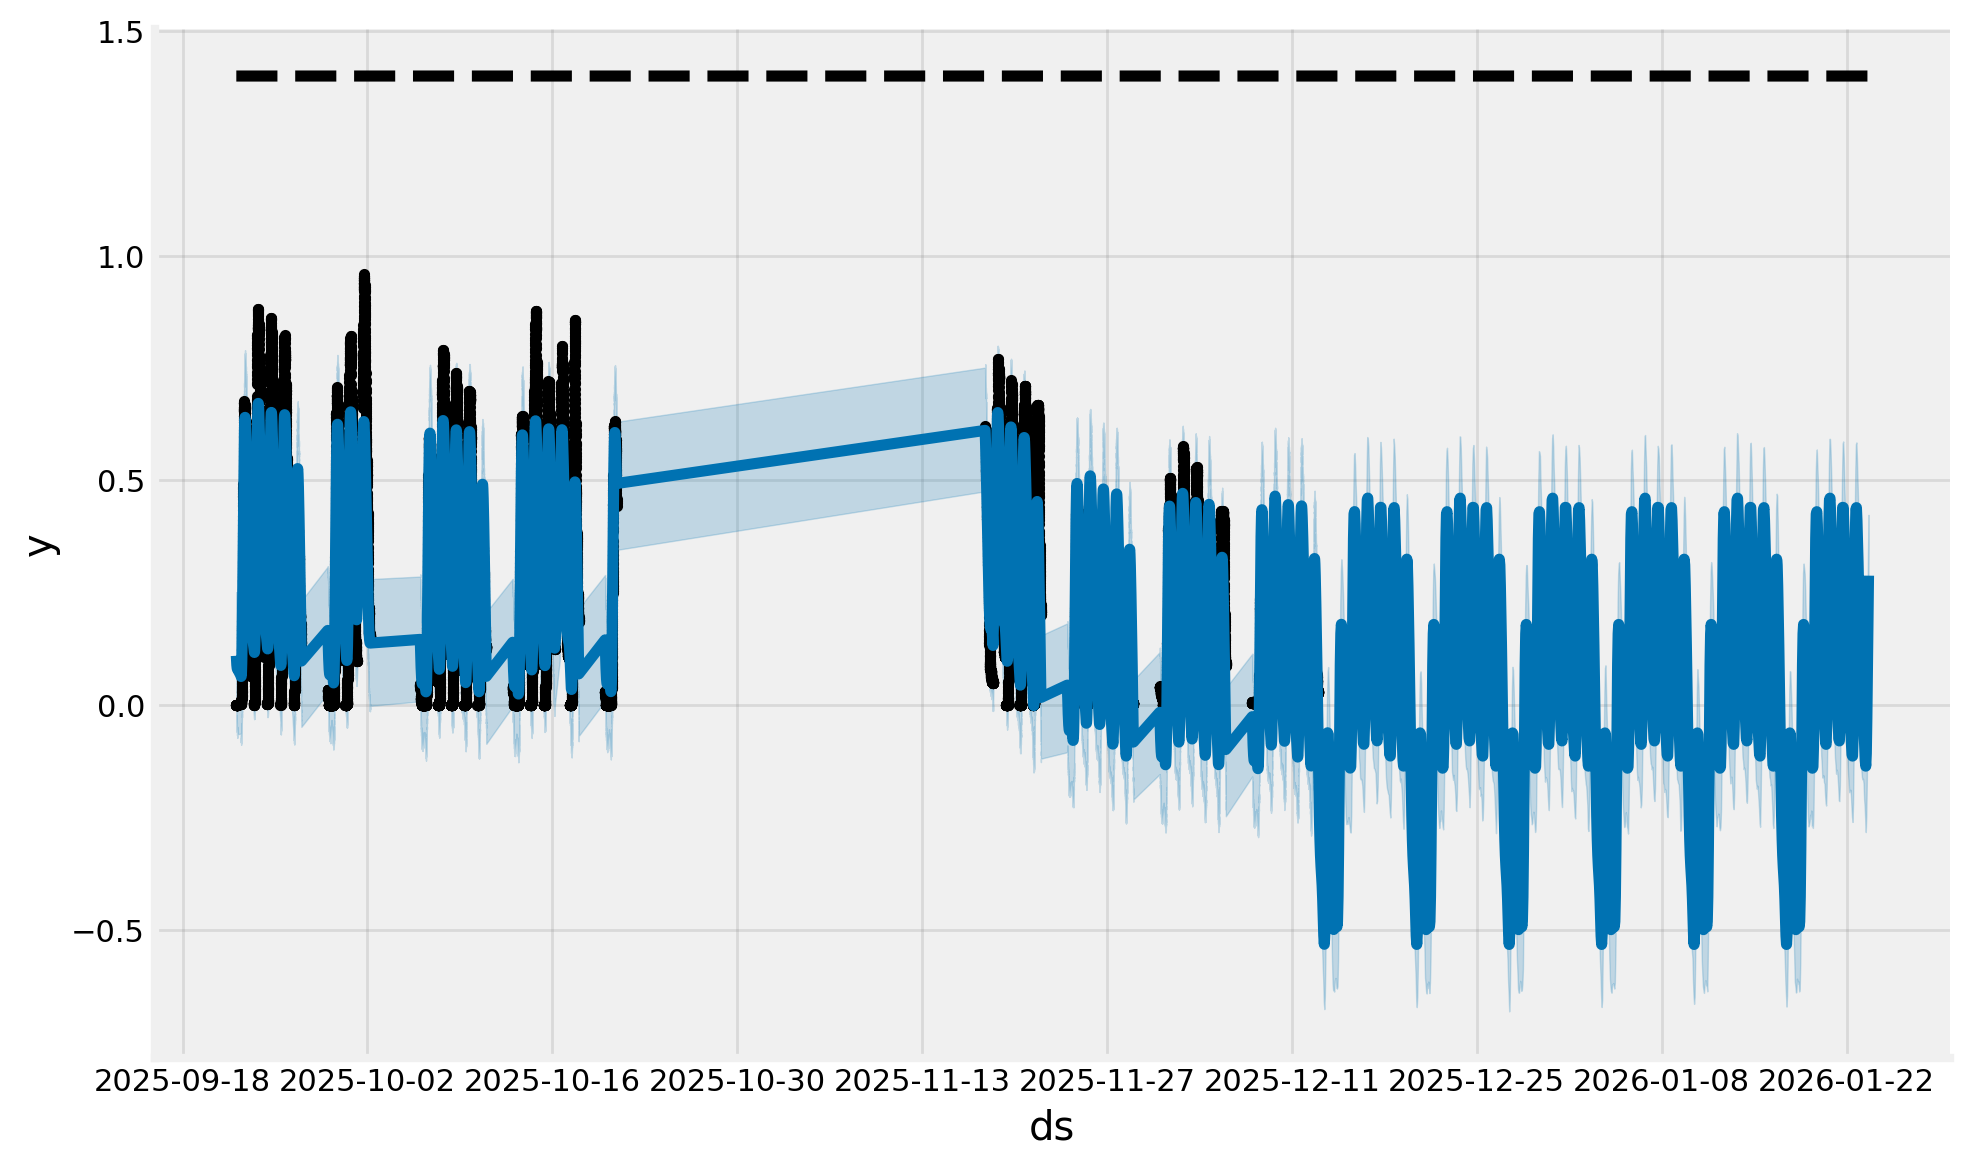

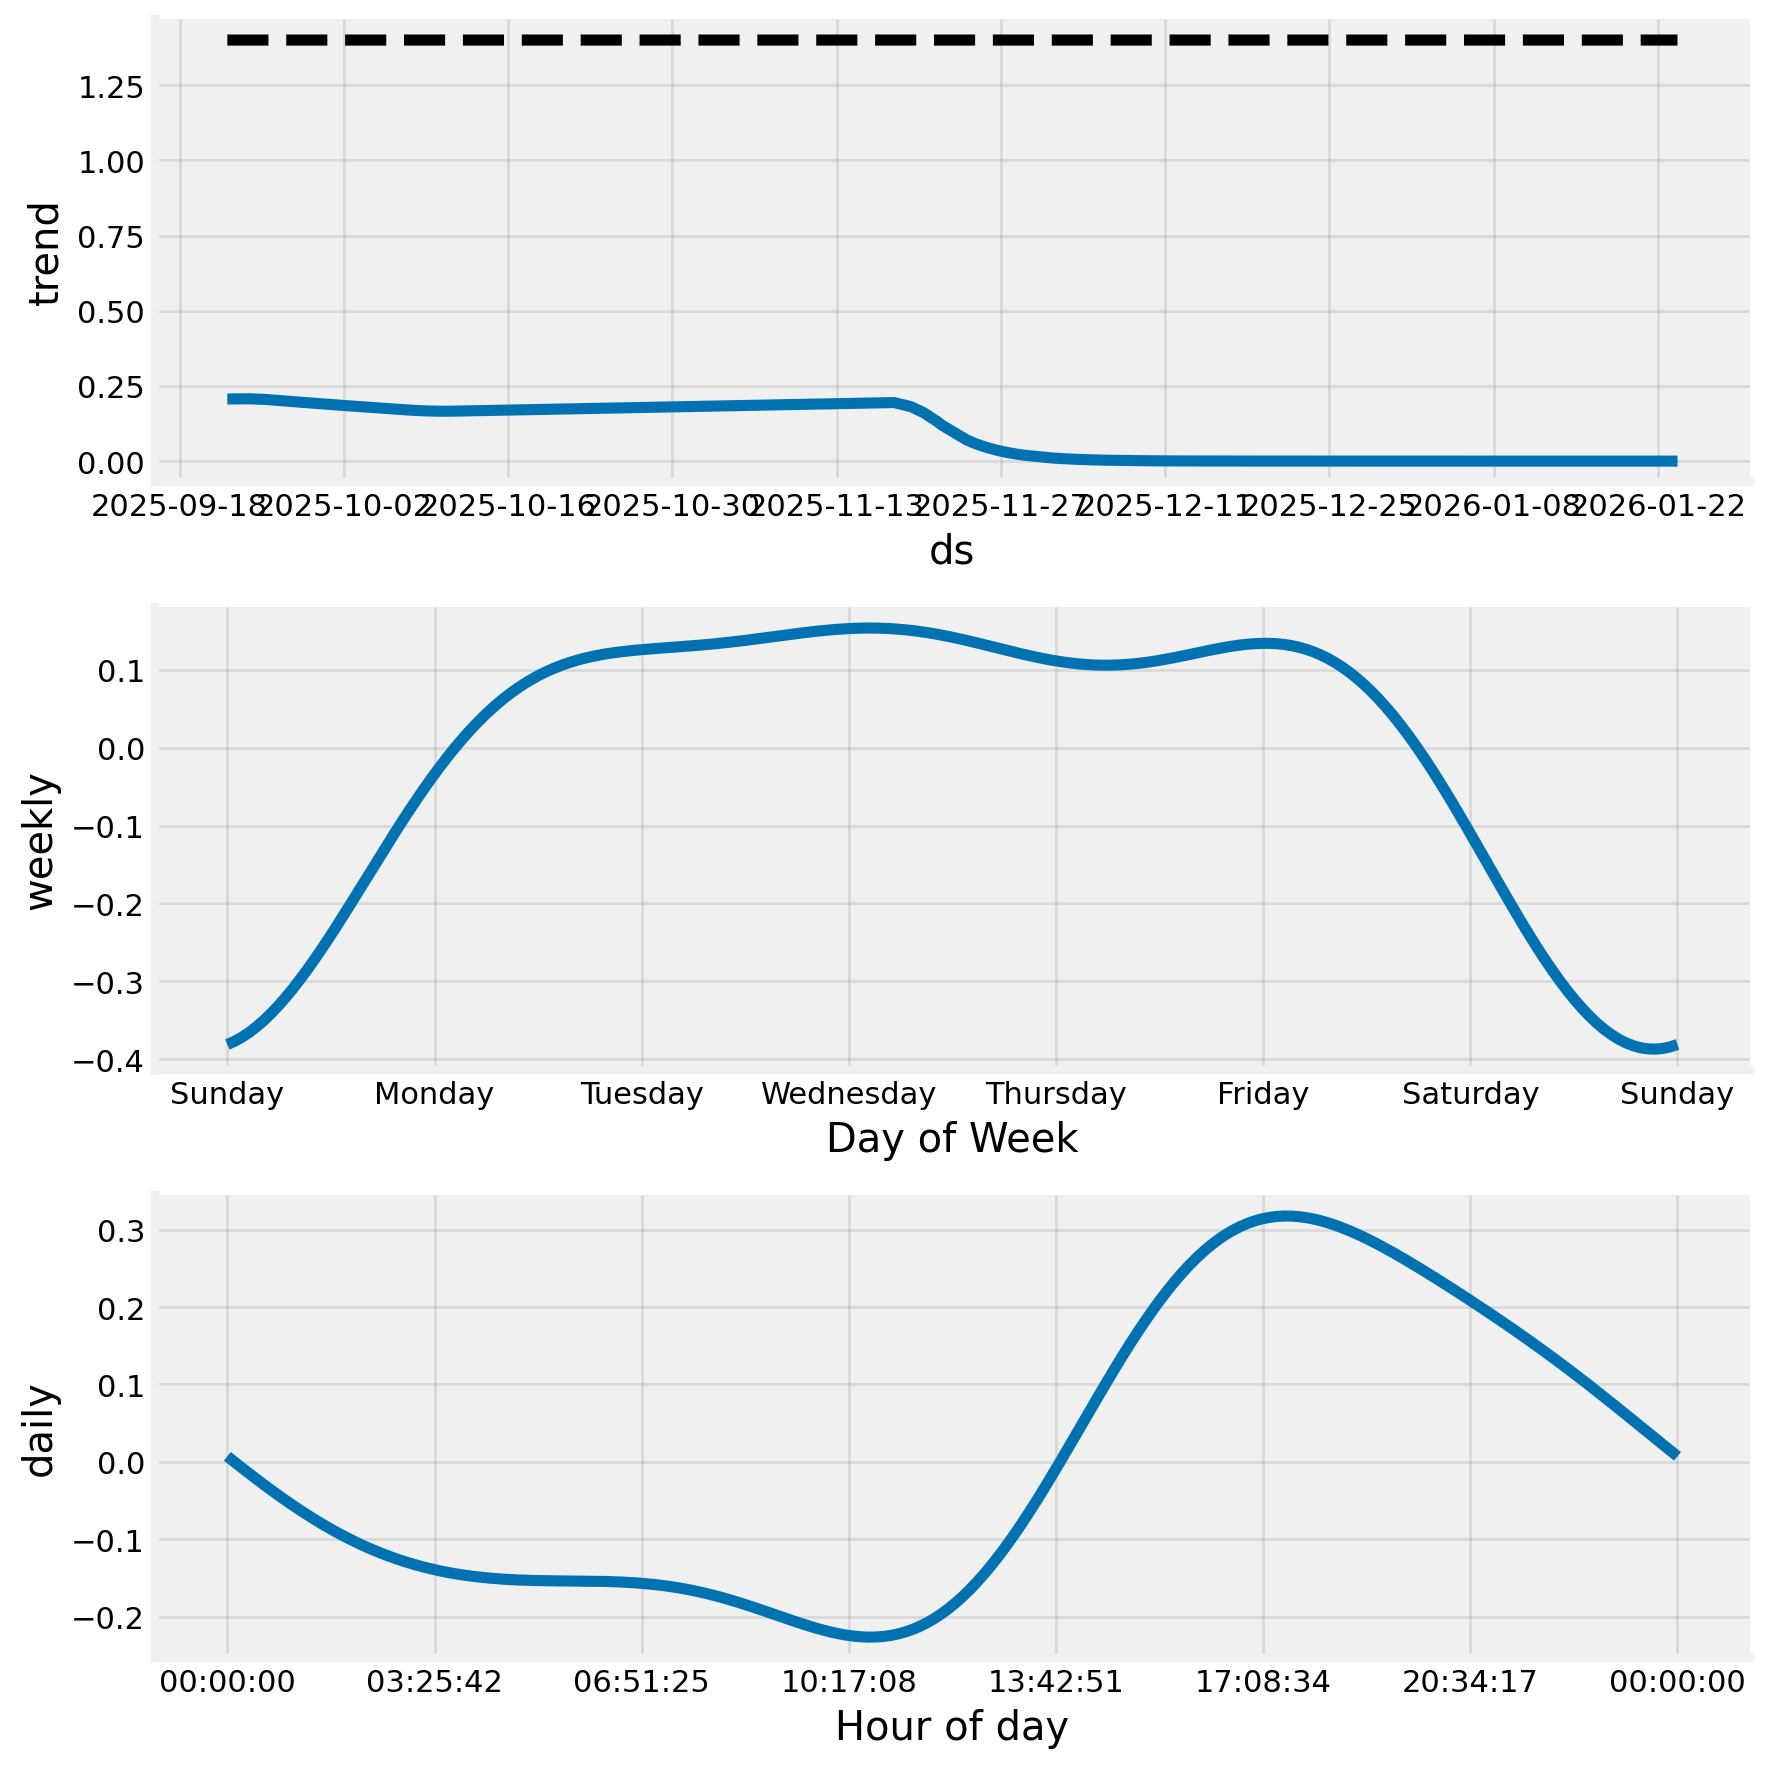

In [49]:
future = m.make_future_dataframe(periods=1000, freq='h')
future['cap'] = 1.4
fcst = m.predict(future)
fig1 = m.plot(fcst)
fig2 = m.plot_components(fcst)

In [50]:
# # Create custom function
# # Google style docstrings
# # https://sphinxcontrib-napoleon.readthedocs.io/en/latest/example_google.html
# def custom_function(param1: int, param2: str) -> bool:
#     """Example function with PEP 484 type annotations.

#     Args:
#         param1: The first parameter.
#         param2: The second parameter.

#     Returns:
#         The return value. True for success, False otherwise.

#     """

In [51]:
# # Apply function to multiple columns
# cols = []
# df_updated = df.copy()
# df_updated[cols] = df_updated[cols].applymap(custom_function)

# # Create new aggregated boolean column
# df_updated['bool'] = df_updated[cols].any(axis=1, skipna=False)

---

# 4

## Data Analysis

Here is where your analysis begins. You can add different sections based on your project goals.

### Exploring `Column Name`

In [52]:
# Code and visualization

**Observations**
- Ob 1
- Ob 2
- Ob 3

---

# 5

## Conclusion

### Insights 
State the insights/outcomes of your project or notebook.

### Suggestions

Make suggestions based on insights.

### Possible Next Steps
Areas to expand on:
- (if there is any)

---

# 6

## Epilogue

### References

This is how we use inline citation[<sup id="fn1-back">[1]</sup>](#fn1).

[<span id="fn1">1.</span>](#fn1-back) _Author (date)._ Title. Available at: https://website.com (Accessed: Date). 

> Use [https://www.citethisforme.com/](https://www.citethisforme.com/) to create citations.

### Versioning
Notebook and insights by (author).
- Version: 1.5.0
- Date: 2023-05-15

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b689e16b-e36c-4f8c-b17a-b3e876352669' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>